<a href="https://colab.research.google.com/github/CarlosJB95/PathIA-MSI-colon/blob/main/Notebook_04_Imagen_como_dato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 04 · Imagen como dato — Pillow (open / crop / resize)**

**Ruta PathIA 3.0 · Mes 1 · Semana 4 · Día 16**
**Fecha:** lunes 14 de septiembre de 2026

---

## 🎯 Objetivo del día
Dar el salto de **datos tabulares** a **imagen como dato**: entender que una imagen
digital es una **matriz de píxeles** y aprender las tres operaciones base con Pillow.

- `Image.open`, `.size`, `.mode` → abrir e interrogar una imagen.
- `.crop` → extraer un campo (ROI) registrando sus **coordenadas**.
- `.resize` → cambiar el detalle disponible (↔ magnificación / MPP).
- Prototipo de *tiling*: `recortar_campos()` (mosaico 2×2 con manifest de coordenadas).

## 🔬 Puente clínico
Al microscopio recortas mentalmente un **campo (ROI)** de la laminilla y cambias de
objetivo (4x↔40x) para ver más o menos **detalle**. Hoy haces lo mismo en código:
`crop` selecciona el campo, `resize` cambia el detalle. Antesala del *tiling* de WSI (Mes 2).

## 📦 Recursos
- Dataset: **NCT-CRC-HE-100K** (parches H&E de colon).
- Documentación: Pillow (`PIL.Image`).

---

> ⚠️ **Data card:** material de aprendizaje — **sin uso clínico**.
> Semilla global fijada (`random.seed(42)`, `np.random.seed(42)`) para reproducibilidad.

In [ ]:
"""Celda 2 · Configuración del entorno y reproducibilidad.

Imports base del Notebook 04 y fijación de la semilla global.
La semilla se fija UNA vez, al inicio, para que todo el notebook
sea reproducible con 'Restart & run all'.
"""

# --- Librerías estándar ---
import random
from pathlib import Path

# --- Terceros ---
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- Reproducibilidad: semilla global (se fija una sola vez) ---
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

# --- Rutas trazables del repo (ajusta la base a tu montaje en Colab) ---
BASE = Path("01_colon_eda")
DIR_PARCHES = BASE / "data" / "parches"          # tiles de NCT-CRC-HE-100K
DIR_RESULTS = BASE / "results" / "parches_demo"  # salidas de hoy (crops)
DIR_RESULTS.mkdir(parents=True, exist_ok=True)   # crea la carpeta si no existe

# --- Verificación rápida de versiones (útil para el data card) ---
import PIL, matplotlib
print("Pillow :", PIL.__version__)
print("NumPy  :", np.__version__)
print("MPL    :", matplotlib.__version__)
print("Semilla:", SEMILLA)
print("Salidas en:", DIR_RESULTS)

Pillow : 11.3.0
NumPy  : 2.1.3
MPL    : 3.10.0
Semilla: 42
Salidas en: 01_colon_eda/results/parches_demo


In [ ]:
"""Celda 3 (corregida) · Tiles reales de NCT-CRC-HE vía parquet.

La versión nueva de 'datasets' no admite scripts de carga; usamos un
mirror parquet-nativo. streaming=True → no baja todo el dataset.
"""
from datasets import load_dataset

N_TILES = 6
REPO = "junyeong-nero/mini-NCTCRCHE100K"   # parquet-nativo, 9 clases, ligero

DIR_PARCHES.mkdir(parents=True, exist_ok=True)

ds = load_dataset(REPO, split="train", streaming=True)

feats = getattr(ds, "features", None)
nombres_clase = feats["label"].names if feats and "label" in feats else None

rutas_guardadas = []
for i, ejemplo in enumerate(ds):
    if i >= N_TILES:
        break
    img = ejemplo["image"]                       # objeto PIL.Image
    etiqueta = ejemplo["label"]
    clase = nombres_clase[etiqueta] if nombres_clase else f"cls{etiqueta}"
    ruta = DIR_PARCHES / f"nct_train_{i:03d}_{clase}.png"
    img.save(ruta)
    rutas_guardadas.append(ruta)
    print(f"guardado: {ruta.name}  |  size={img.size}  mode={img.mode}")

print(f"\n{len(rutas_guardadas)} parches en: {DIR_PARCHES}")

guardado: nct_train_000_LYM.png  |  size=(224, 224)  mode=RGB
guardado: nct_train_001_MUS.png  |  size=(224, 224)  mode=RGB
guardado: nct_train_002_STR.png  |  size=(224, 224)  mode=RGB
guardado: nct_train_003_STR.png  |  size=(224, 224)  mode=RGB
guardado: nct_train_004_BACK.png  |  size=(224, 224)  mode=RGB
guardado: nct_train_005_BACK.png  |  size=(224, 224)  mode=RGB

6 parches en: 01_colon_eda/data/parches


tipo : <class 'PIL.PngImagePlugin.PngImageFile'>
size : (224, 224)
mode : RGB
px(0,0)  : (175, 112, 165)
px(112,112): (183, 115, 170)


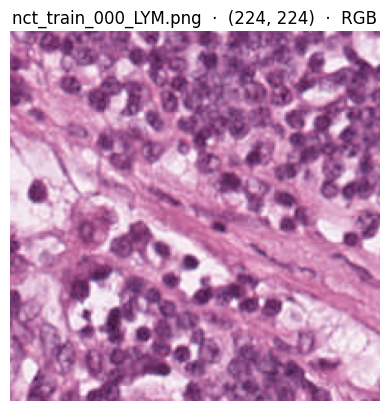

In [ ]:
# Abrir UN parche e interrogarlo (imagen como dato)
ruta = DIR_PARCHES / "nct_train_000_LYM.png"
img = Image.open(ruta)

print("tipo :", type(img))          # objeto Image de Pillow
print("size :", img.size)           # (ancho, alto) en px
print("mode :", img.mode)           # cadena: 'RGB'
print("px(0,0)  :", img.getpixel((0, 0)))       # esquina sup-izq → (R,G,B)
print("px(112,112):", img.getpixel((112, 112))) # centro del parche → (R,G,B)

plt.imshow(img)
plt.title(f"{ruta.name}  ·  {img.size}  ·  {img.mode}")
plt.axis("off")
plt.show()

caja      : (56, 56, 168, 168)
size crop : (112, 112)


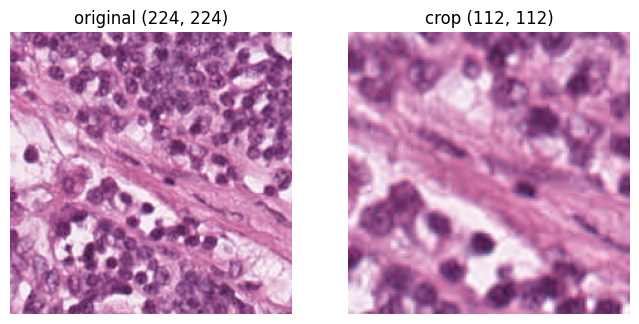

In [ ]:
# Recorte del cuadrante central (ROI) con coordenadas explícitas
caja = (56, 56, 168, 168)          # (left, upper, right, lower)
centro = img.crop(caja)

print("caja      :", caja)
print("size crop :", centro.size)   # ¿qué esperas aquí?

# Comparar original vs recorte
fig, (a, b) = plt.subplots(1, 2, figsize=(8, 4))
a.imshow(img);    a.set_title(f"original {img.size}");    a.axis("off")
b.imshow(centro); b.set_title(f"crop {centro.size}");     b.axis("off")
plt.show()

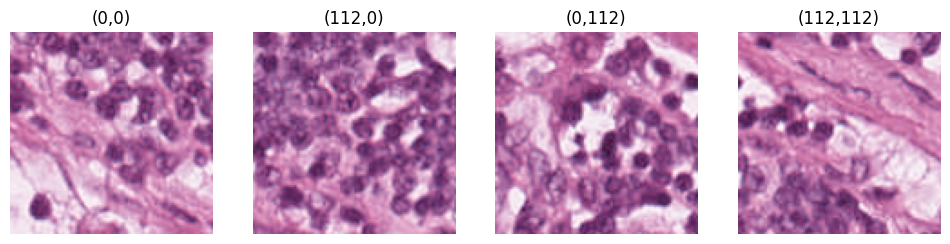

{'slide_id': 'nct_train_000_LYM', 'x0': 0, 'y0': 0, 'x1': 112, 'y1': 112, 'ancho': 112, 'alto': 112}
{'slide_id': 'nct_train_000_LYM', 'x0': 112, 'y0': 0, 'x1': 224, 'y1': 112, 'ancho': 112, 'alto': 112}
{'slide_id': 'nct_train_000_LYM', 'x0': 0, 'y0': 112, 'x1': 112, 'y1': 224, 'ancho': 112, 'alto': 112}
{'slide_id': 'nct_train_000_LYM', 'x0': 112, 'y0': 112, 'x1': 224, 'y1': 224, 'ancho': 112, 'alto': 112}


In [ ]:
# Prototipo de manifest: cada recorte registra su origen y su caja
slide_id = ruta.stem                 # "nct_train_000_LYM" — de qué parche salió

cajas = [
    (0,   0,   112, 112),            # cuadrante superior-izquierdo
    (112, 0,   224, 112),            # superior-derecho
    (0,   112, 112, 224),            # inferior-izquierdo
    (112, 112, 224, 224),            # inferior-derecho
]

manifest = []
recortes = []
for i, caja in enumerate(cajas):
    sub = img.crop(caja)
    recortes.append(sub)
    x0, y0, x1, y1 = caja
    manifest.append({
        "slide_id": slide_id,
        "x0": x0, "y0": y0, "x1": x1, "y1": y1,
        "ancho": x1 - x0, "alto": y1 - y0,
    })

# Visualiza los 4 sub-parches
fig, ejes = plt.subplots(1, 4, figsize=(12, 3))
for ax, sub, m in zip(ejes, recortes, manifest):
    ax.imshow(sub)
    ax.set_title(f"({m['x0']},{m['y0']})")
    ax.axis("off")
plt.show()

# Inspecciona el manifest
for fila in manifest:
    print(fila)

In [ ]:
# Guardar cada sub-parche con nombre trazable: de qué slide y qué caja
rutas_tiles = []
for sub, m in zip(recortes, manifest):
    nombre = f"{m['slide_id']}_x{m['x0']}_y{m['y0']}.png"   # p.ej. nct_train_000_LYM_x112_y0.png
    destino = DIR_RESULTS / nombre
    sub.save(destino)
    rutas_tiles.append(destino)
    print("guardado:", destino.name)

print(f"\n{len(rutas_tiles)} tiles en: {DIR_RESULTS}")

guardado: nct_train_000_LYM_x0_y0.png
guardado: nct_train_000_LYM_x112_y0.png
guardado: nct_train_000_LYM_x0_y112.png
guardado: nct_train_000_LYM_x112_y112.png

4 tiles en: 01_colon_eda/results/parches_demo


## Resumen — bloque mañana (Día 16)
Imagen digital = **matriz de píxeles**. Operaciones base de Pillow:
- `Image.open(ruta)` → objeto imagen; se interroga con `.size` (ancho, alto),
  `.mode` ('RGB' = etiqueta de 3 canales), `.getpixel((x,y))` → (R,G,B).
- `.crop((left, upper, right, lower))` → ROI por **dos esquinas**; rango
  semiabierto [x0,x1). Cada recorte se registra en un **manifest** {slide_id, x0,y0,x1,y1}.
- Lectura de píxel: R<B → hematoxilínico (núcleo); R>B → eosinofílico.
  Un píxel es anécdota; la señal está en la distribución sobre el campo.

**Pendiente tarde:** `resize` (↔ magnificación/MPP), función `recortar_campos`, casos límite.

original     : (224, 224)
reducido     : (112, 112)
reconstruido : (224, 224)


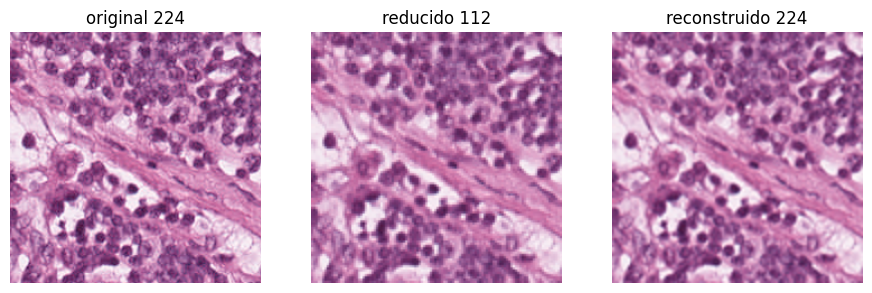

In [ ]:
# resize: reducir y volver a ampliar — ¿se recupera el detalle?
original = img                                    # 224x224
reducido = original.resize((112, 112))            # baja de "40x" a "10x"
reconstruido = reducido.resize((224, 224))        # intenta volver a "40x"

print("original     :", original.size)
print("reducido     :", reducido.size)
print("reconstruido :", reconstruido.size)

fig, ejes = plt.subplots(1, 3, figsize=(11, 4))
for ax, im, t in zip(ejes,
                     [original, reducido, reconstruido],
                     ["original 224", "reducido 112", "reconstruido 224"]):
    ax.imshow(im); ax.set_title(t); ax.axis("off")
plt.show()

In [ ]:
import numpy as np

orig_arr  = np.asarray(original,     dtype=np.int16)
recon_arr = np.asarray(reconstruido, dtype=np.int16)

# Diferencia absoluta media por píxel (0 = idénticas)
dif = np.abs(orig_arr - recon_arr)
print("diferencia media por canal (0-255):", dif.mean().round(2))
print("diferencia máxima en algún píxel  :", dif.max())

diferencia media por canal (0-255): 5.35
diferencia máxima en algún píxel  : 50


In [ ]:
def recortar_campos(img, tam=112, descartar_borde=True):
    """Trocea una imagen en tiles de lado `tam`.

    Args:
        img: PIL.Image a trocear.
        tam (int): lado del tile en píxeles.
        descartar_borde (bool): si True, omite tiles que rebasan el borde
            (tiles incompletos); si False, los incluye con relleno.

    Returns:
        list[tuple]: (sub_imagen, caja) con caja = (x0, y0, x1, y1).
    """
    ancho, alto = img.size
    campos = []
    for y in range(0, alto, tam):
        for x in range(0, ancho, tam):
            caja = (x, y, x + tam, y + tam)
            if descartar_borde and (caja[2] > ancho or caja[3] > alto):
                continue                     # rebasa el borde → lo saltamos
            campos.append((img.crop(caja), caja))
    return campos

In [ ]:
campos = recortar_campos(img, tam=100, descartar_borde=True)
print("tiles válidos con tam=100:", len(campos))
for sub, caja in campos:
    print(f"caja={caja}  size={sub.size}")

tiles válidos con tam=100: 4
caja=(0, 0, 100, 100)  size=(100, 100)
caja=(100, 0, 200, 100)  size=(100, 100)
caja=(0, 100, 100, 200)  size=(100, 100)
caja=(100, 100, 200, 200)  size=(100, 100)


git add 04_imagen_como_dato.ipynb
git commit -m "Día 16: imagen como dato — open/crop/resize + recortar_campos con filtro de borde y manifest"

## **Día 17 · Semana 4 · Mes 1 — Imagen a array de NumPy: canales RGB e histograma de intensidad**

---



In [ ]:
arr = np.array(Image.open(DIR_PARCHES / "nct_train_000_LYM.png"))
print("shape:", arr.shape)
print("dtype:", arr.dtype)
print("min / max:", arr.min(), arr.max())

shape: (224, 224, 3)
dtype: uint8
min / max: 13 255


In [ ]:
R = arr[:, :, 0]
G = arr[:, :, 1]
B = arr[:, :, 2]
print("shape de R:", R.shape)

shape de R: (224, 224)


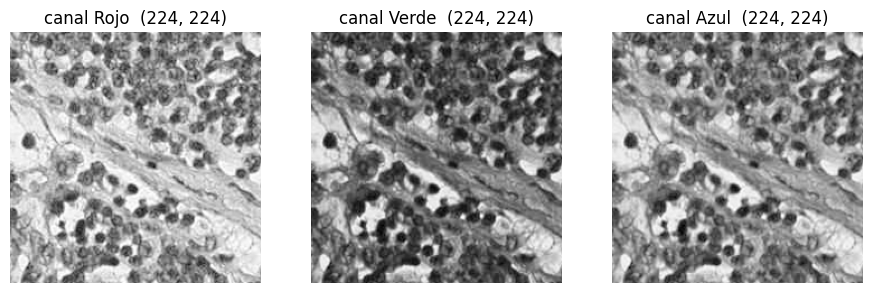

In [ ]:
R = arr[:, :, 0]
G = arr[:, :, 1]
B = arr[:, :, 2]

fig, ejes = plt.subplots(1, 3, figsize=(11, 4))
for ax, canal, nombre in zip(ejes, [R, G, B], ["Rojo", "Verde", "Azul"]):
    ax.imshow(canal, cmap='gray')
    ax.set_title(f"canal {nombre}  {canal.shape}")
    ax.axis("off")
plt.show()

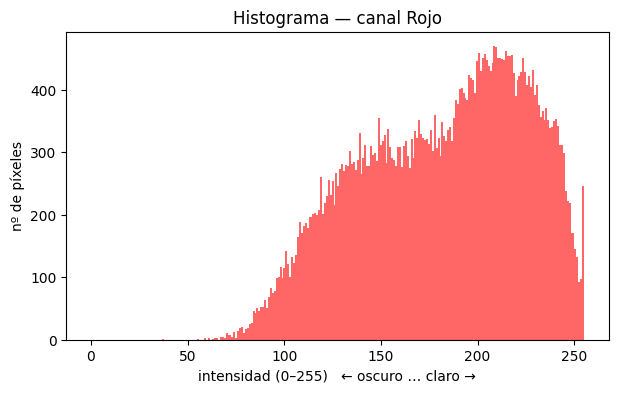

R aplanado: (50176,)


In [ ]:
R = arr[:, :, 0]

plt.figure(figsize=(7, 4))
plt.hist(R.flatten(), bins=256, range=(0, 255), color='red', alpha=0.6)
plt.title("Histograma — canal Rojo")
plt.xlabel("intensidad (0–255)   ← oscuro … claro →")
plt.ylabel("nº de píxeles")
plt.show()

print("R aplanado:", R.flatten().shape)

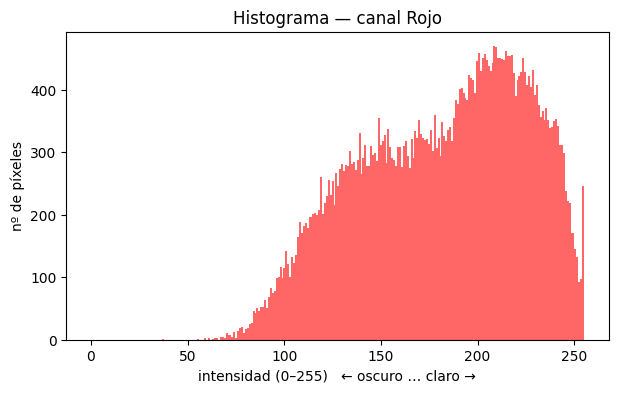

In [ ]:
R = arr[:, :, 0]

plt.figure(figsize=(7, 4))
plt.hist(R.flatten(), bins=256, range=(0, 255), color='red', alpha=0.6)
plt.title("Histograma — canal Rojo")
plt.xlabel("intensidad (0–255)   ← oscuro … claro →")
plt.ylabel("nº de píxeles")
plt.show()

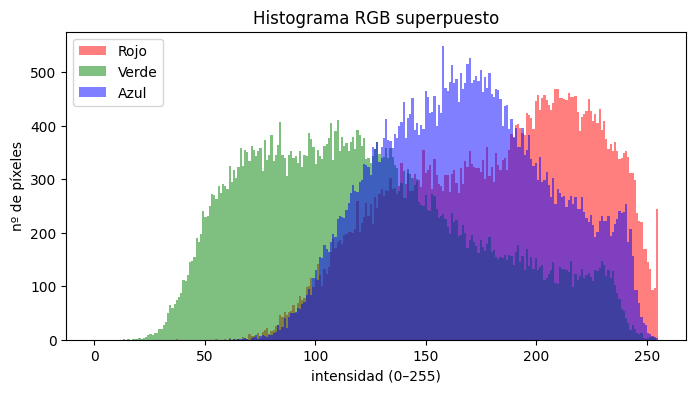

In [ ]:
plt.figure(figsize=(8, 4))
for i, (nombre, c) in enumerate(zip(["Rojo", "Verde", "Azul"], ["red", "green", "blue"])):
    plt.hist(arr[:, :, i].flatten(), bins=256, range=(0, 255),
             color=c, alpha=0.5, label=nombre)
plt.legend(); plt.title("Histograma RGB superpuesto")
plt.xlabel("intensidad (0–255)"); plt.ylabel("nº de píxeles")
plt.show()

In [ ]:
from pathlib import Path
DIR_HIST = Path("01_colon_eda/results/histogramas")
DIR_HIST.mkdir(parents=True, exist_ok=True)

# (vuelve a generar la figura RGB y, antes de plt.show(), guárdala)
plt.savefig(DIR_HIST / "nct_train_000_LYM_hist_rgb.png", dpi=120, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
def histograma_canales(arr, bins=256):
    """Traza los histogramas RGB de un parche y devuelve estadísticos por canal.

    Args:
        arr: np.array (alto, ancho, 3), uint8.
        bins (int): número de bins del histograma.

    Returns:
        dict: {'R': {...}, 'G': {...}, 'B': {...}} con media, mediana y SD por canal.
    """
    nombres = ["R", "G", "B"]
    colores = ["red", "green", "blue"]

    # Estadísticos por canal: colapsa alto y ancho (axis=(0,1)), sobreviven los 3 canales
    medias   = arr.mean(axis=(0, 1))
    medianas = np.median(arr, axis=(0, 1))
    sds      = arr.std(axis=(0, 1))

    # Histograma superpuesto
    plt.figure(figsize=(8, 4))
    for i, (nom, col) in enumerate(zip(nombres, colores)):
        plt.hist(arr[:, :, i].flatten(), bins=bins, range=(0, 255),
                 color=col, alpha=0.5, label=nom)
    plt.legend(); plt.xlabel("intensidad (0–255)"); plt.ylabel("nº de píxeles")
    plt.show()

    # Empaqueta los estadísticos en un dict trazable
    stats = {}
    for i, nom in enumerate(nombres):
        stats[nom] = {"media": round(float(medias[i]), 1),
                      "mediana": float(medianas[i]),
                      "sd": round(float(sds[i]), 1)}
    return stats

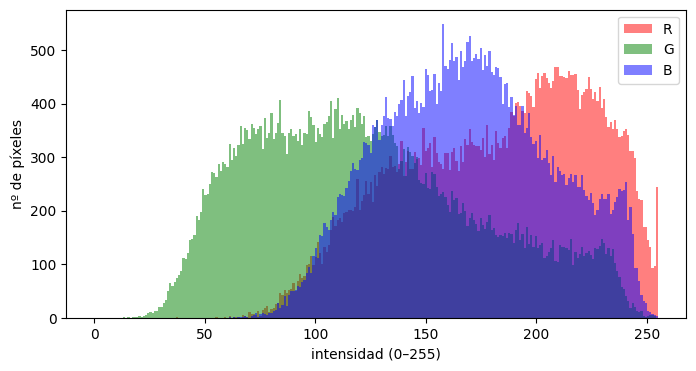

{'R': {'media': 182.0, 'mediana': 188.0, 'sd': 42.7},
 'G': {'media': 123.1, 'mediana': 117.0, 'sd': 51.1},
 'B': {'media': 169.0, 'mediana': 168.0, 'sd': 38.0}}

In [ ]:
stats = histograma_canales(arr)
stats

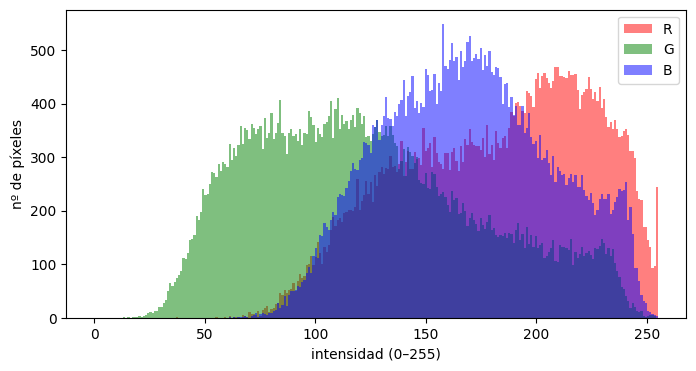

nct_train_000_LYM.png → {'R': {'media': 182.0, 'mediana': 188.0, 'sd': 42.7}, 'G': {'media': 123.1, 'mediana': 117.0, 'sd': 51.1}, 'B': {'media': 169.0, 'mediana': 168.0, 'sd': 38.0}}


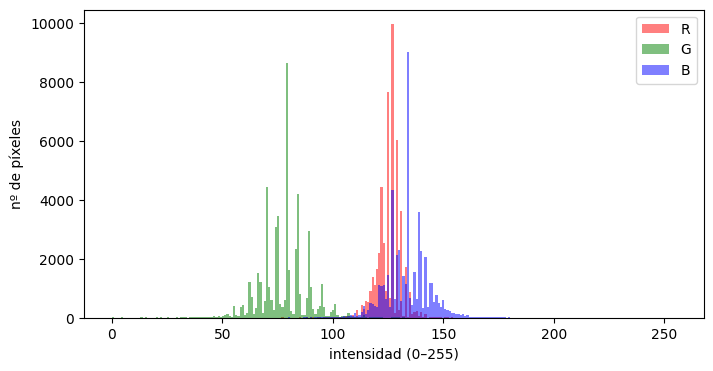

nct_train_004_BACK.png → {'R': {'media': 125.1, 'mediana': 125.0, 'sd': 7.8}, 'G': {'media': 78.1, 'mediana': 79.0, 'sd': 12.7}, 'B': {'media': 133.4, 'mediana': 134.0, 'sd': 11.8}}


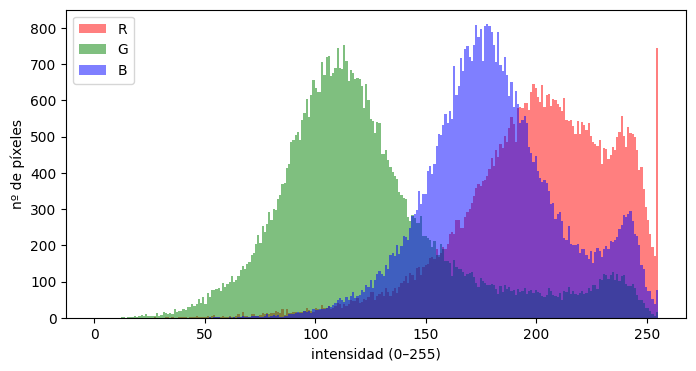

nct_train_001_MUS.png → {'R': {'media': 201.2, 'mediana': 204.0, 'sd': 34.1}, 'G': {'media': 124.3, 'mediana': 116.0, 'sd': 42.4}, 'B': {'media': 181.8, 'mediana': 179.0, 'sd': 31.0}}


In [ ]:
for nombre in ["nct_train_000_LYM.png", "nct_train_004_BACK.png", "nct_train_001_MUS.png"]:
    arr_i = np.array(Image.open(DIR_PARCHES / nombre))
    print(nombre, "→", histograma_canales(arr_i))

In [ ]:
# 1. Normalización a [0,1]
arr_norm = arr.astype(np.float32) / 255.0
print("norm min/max:", arr_norm.min(), arr_norm.max())

# 2. Gris promediando canales (pierde la tinción)
gris = arr.mean(axis=2)
print("gris shape:", gris.shape)

norm min/max: 0.050980393 1.0
gris shape: (224, 224)


In [ ]:
def es_fondo(arr, umbral_sd=15):
    """Marca un parche como fondo si es demasiado uniforme (SD baja en todos los canales)."""
    sds = arr.std(axis=(0, 1))        # SD por canal → (3,)
    return bool((sds < umbral_sd).all())  # fondo solo si los 3 canales son uniformes

for nombre in ["nct_train_000_LYM.png", "nct_train_004_BACK.png", "nct_train_001_MUS.png"]:
    a = np.array(Image.open(DIR_PARCHES / nombre))
    print(nombre, "→ ¿fondo?", es_fondo(a))

nct_train_000_LYM.png → ¿fondo? False
nct_train_004_BACK.png → ¿fondo? True
nct_train_001_MUS.png → ¿fondo? False


In [33]:
import os
from getpass import getpass

# 1. El token entra a una variable, sin verse en pantalla
os.environ["GH_TOKEN"] = getpass("Pega tu token NUEVO aquí: ")

# 2. La URL del remoto queda LIMPIA (sin token) → nunca se imprime en errores
!git remote set-url origin https://github.com/CarlosJB95/PathIA-MSI-colon.git

# 3. Un ayudante le entrega el token a git desde la variable
!git config credential.helper '!f() { echo "username=CarlosJB95"; echo "password=$GH_TOKEN"; }; f'

# 4. El push ya no lleva el token en el comando
!git push origin main

Pega tu token NUEVO aquí: ··········
Enumerating objects: 14, done.
Counting objects: 100% (14/14), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (8/8), 843 bytes | 843.00 KiB/s, done.
Total 8 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/CarlosJB95/PathIA-MSI-colon.git
   a8007dc..85d81b7  main -> main


In [34]:
!git log --oneline -5      # ¿aparece arriba tu commit "Día 18: mover Notebook 04"?
!echo "-----"
!ls notebooks/             # ¿está Notebook_04 físicamente dentro?
!echo "-----"
!git status                # ¿"working tree clean" y "up to date with origin/main"?

85d81b7 (HEAD -> main, origin/main, origin/HEAD) Día 18: estructura de repo reproducible (notebooks/src/configs/splits/results/data_cards)
a8007dc git add 04_imagen_como_dato.ipynb git commit -m "Día 17: imagen→np.array, canales RGB, histograma, histograma_canales + QC por SD"
7810ccb git add 04_imagen_como_dato.ipynb git commit -m "Día 16: imagen como dato — open/crop/resize + recortar_campos con filtro de borde y manifest"
e922993 Add files via upload
c3e1aba Delete notebooks/Notebook_Semana_03.ipynb
-----
Notebook_03_Visualizaciones.ipynb  Notebook_Semana_02.ipynb
Notebook_Semana_01.ipynb	   README.md
-----
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
